In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series as fpppy_plot_series

import matplotlib.figure
matplotlib.figure.Figure.show = lambda self, *a, **k: None

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

In [3]:
import sys
from pathlib import Path

In [4]:
cwd = Path.cwd()
project_root = cwd.parent
project_root

PosixPath('/Users/ak007/Projects/TS')

In [5]:
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


## Q1

1. Explore the following four time series: Bricks from aus_production, Lynx from pelt, GOOG_Close from gafa_stock, Demand from vic_elec.

- Use .info() to find out about the data in each series.
- What is the time interval of each series?
- Use plot_series() to produce a time plot of each series.
- For the last plot, modify the axis labels and title.

In [6]:
aus_prod = pd.read_csv(
    project_root / "data" / "aus_production.csv",
    parse_dates=["ds"]
)

In [10]:
aus_prod_bricks = aus_prod[["ds", "Bricks"]]
aus_prod_bricks.head()

,ds,Bricks
0,1956-01-01,189.0
1,1956-04-01,204.0
2,1956-07-01,208.0
3,1956-10-01,197.0
4,1957-01-01,187.0


In [11]:
aus_prod_bricks.info()

<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      218 non-null    datetime64[us]
 1   Bricks  198 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 3.5 KB


In [16]:
aus_prod_bricks.loc[aus_prod_bricks["Bricks"].isna()]

,ds,Bricks
198,2005-07-01,NaN
199,2005-10-01,NaN
200,2006-01-01,NaN
201,2006-04-01,NaN
202,2006-07-01,NaN
203,2006-10-01,NaN
204,2007-01-01,NaN
205,2007-04-01,NaN
206,2007-07-01,NaN
207,2007-10-01,NaN


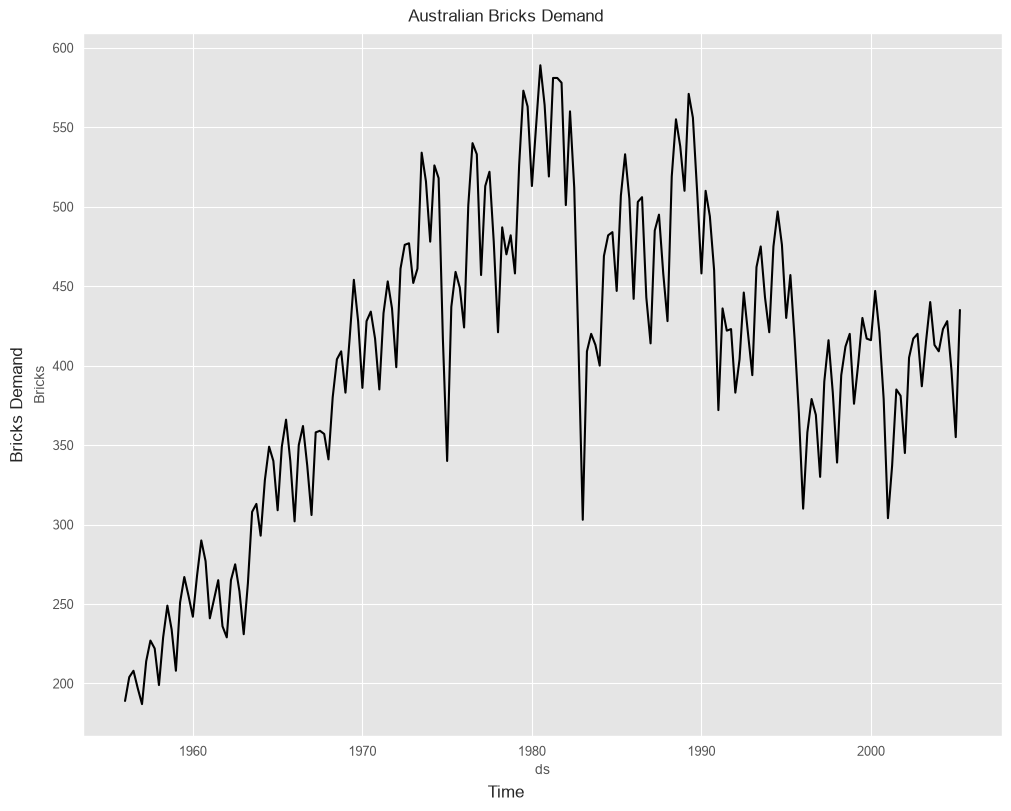

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.lineplot(
    data=aus_prod_bricks,
    x="ds",
    y="Bricks",
    ax=ax
)

fig.suptitle("Australian Bricks Demand")
fig.supxlabel("Time")
fig.supylabel("Bricks Demand")
fig.show()

In [21]:
g_stock = pd.read_csv(
    project_root / "data" / "gafa_stock.csv",
    parse_dates=["ds"]
)

In [22]:
g_stock

,unique_id,ds,y
0,AAPL_Open,2014-01-02,7.938e+01
1,AAPL_Open,2014-01-03,7.898e+01
2,AAPL_Open,2014-01-06,7.678e+01
3,AAPL_Open,2014-01-07,7.776e+01
4,AAPL_Open,2014-01-08,7.697e+01
...,...,...,...
30187,GOOG_Volume,2018-12-24,1.590e+06
30188,GOOG_Volume,2018-12-26,2.373e+06
30189,GOOG_Volume,2018-12-27,2.110e+06
30190,GOOG_Volume,2018-12-28,1.415e+06


In [25]:
g_stock['ds'].iloc[1] - g_stock['ds'].iloc[0]

Timedelta('1 days 00:00:00')

In [23]:
g_stock['unique_id'].unique()

<ArrowStringArray>
[     'AAPL_Open',      'AMZN_Open',        'FB_Open',      'GOOG_Open',
      'AAPL_High',      'AMZN_High',        'FB_High',      'GOOG_High',
       'AAPL_Low',       'AMZN_Low',         'FB_Low',       'GOOG_Low',
     'AAPL_Close',     'AMZN_Close',       'FB_Close',     'GOOG_Close',
 'AAPL_Adj_Close', 'AMZN_Adj_Close',   'FB_Adj_Close', 'GOOG_Adj_Close',
    'AAPL_Volume',    'AMZN_Volume',      'FB_Volume',    'GOOG_Volume']
Length: 24, dtype: str

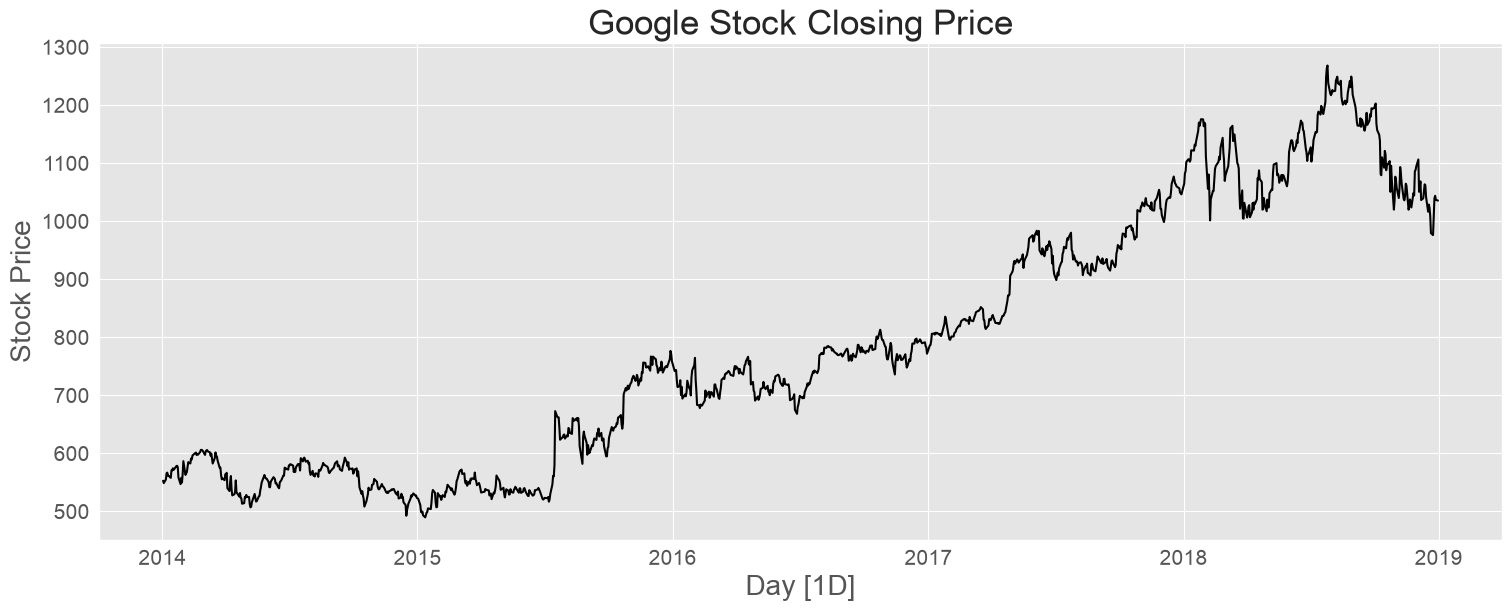

In [27]:
fpppy_plot_series(
    df=g_stock, ids=['GOOG_Close'], time_col="ds", target_col="y",
    xlabel='Day [1D]', ylabel="Stock Price",
    title='Google Stock Closing Price'
)

In [28]:
v_elec = pd.read_csv(
    project_root / "data" / "vic_elec.csv",
    parse_dates=['ds']
)

In [30]:
v_elec.head()

,ds,unique_id,y,Holiday
0,2012-01-01 00:00:00,Demand,4382.825,True
1,2012-01-01 00:30:00,Demand,4263.366,True
2,2012-01-01 01:00:00,Demand,4048.966,True
3,2012-01-01 01:30:00,Demand,3877.563,True
4,2012-01-01 02:00:00,Demand,4036.230,True


In [31]:
v_elec['ds'].iloc[1] - v_elec['ds'].iloc[0]

Timedelta('0 days 00:30:00')

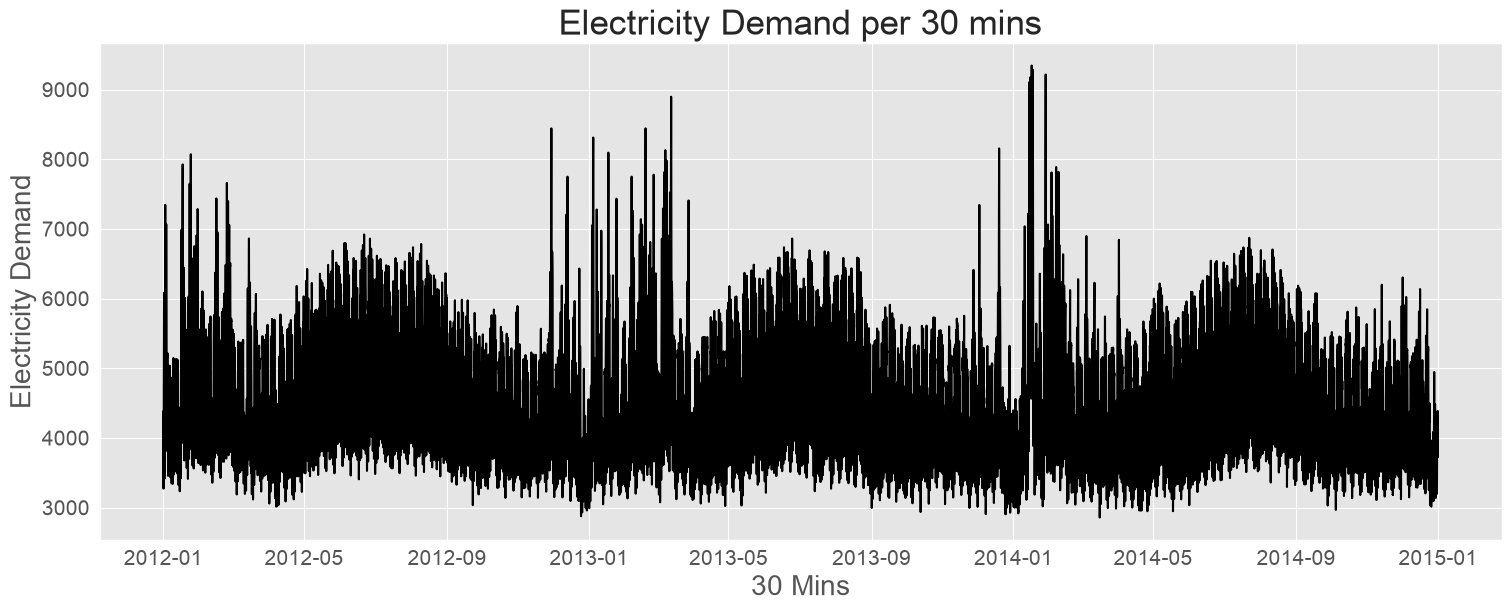

In [32]:
fpppy_plot_series(
    df=v_elec, ids=['Demand'], time_col="ds", target_col="y",
    xlabel='30 Mins', ylabel="Electricity Demand",
    title='Electricity Demand per 30 mins'
)

2. Use .loc[] or query() to find what days corresponded to the peak closing price for each of the four stocks in gafa_stock.

In [ ]:
g_stock.loc[g_stock['unique_id'].isin(["AMZN_Close", "AAPL_Close", "FB_Close", "GOOG_Close"])]

,unique_id,ds,y
15096,AAPL_Close,2014-01-02,79.019
15097,AAPL_Close,2014-01-03,77.283
15098,AAPL_Close,2014-01-06,77.704
15099,AAPL_Close,2014-01-07,77.149
15100,AAPL_Close,2014-01-08,77.637
...,...,...,...
20123,GOOG_Close,2018-12-24,976.220
20124,GOOG_Close,2018-12-26,1039.460
20125,GOOG_Close,2018-12-27,1043.880
20126,GOOG_Close,2018-12-28,1037.080


In [36]:
max_stock_price = g_stock.groupby(by=["unique_id"], as_index=False)["y"].max()

In [37]:
max_stock_price.loc[max_stock_price["unique_id"].isin(["AMZN_Close", "AAPL_Close", "FB_Close", "GOOG_Close"])]

,unique_id,y
1,AAPL_Close,232.07
7,AMZN_Close,2039.51
13,FB_Close,217.50
19,GOOG_Close,1268.33


In [38]:
idx = g_stock.groupby("unique_id")["y"].idxmax()

In [39]:
g_stock.loc[idx]

,unique_id,ds,y
21325,AAPL_Adj_Close,2018-10-03,2.303e+02
16293,AAPL_Close,2018-10-03,2.321e+02
6229,AAPL_High,2018-10-03,2.335e+02
11261,AAPL_Low,2018-10-03,2.298e+02
1198,AAPL_Open,2018-10-04,2.308e+02
25177,AAPL_Volume,2014-01-28,2.664e+08
22562,AMZN_Adj_Close,2018-09-04,2.040e+03
17530,AMZN_Close,2018-09-04,2.040e+03
7466,AMZN_High,2018-09-04,2.050e+03
12498,AMZN_Low,2018-09-04,2.013e+03


In [41]:
max_closing_stock_idx = (
    g_stock
    .groupby(by=['unique_id'])["y"]
    .idxmax()
)

max_closing_stock_prices = (
    g_stock
    .loc[max_closing_stock_idx]
    .query("unique_id in ['AMZN_Close', 'AAPL_Close', 'FB_Close', 'GOOG_Close']")
)

max_closing_stock_prices

,unique_id,ds,y
16293,AAPL_Close,2018-10-03,232.07
17530,AMZN_Close,2018-09-04,2039.51
18760,FB_Close,2018-07-25,217.50
20019,GOOG_Close,2018-07-26,1268.33
